<a href="https://colab.research.google.com/github/K-Atina/Data-Sprint/blob/main/DataSprint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DataSprint 2026 — FinAccess Kenya Financial Status Prediction
**Strathmore Data Community × iLab Africa**

**Team**: [Your Team Name]\
**Date**: June 2026\
**Dataset**: 2024 FinAccess Household Survey (20,871 respondents × 28 features)\
**Target**: Predict whether a Kenyan adult's financial situation has Improved, Stayed the same, or Worsened

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (f1_score, classification_report,
                              ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_excel('/content/finaccess2024_datasprint.xlsx')

In [ ]:
df.head(10)

,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,...,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,...,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,...,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,...,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,NaN,Without Disability
5,Kilifi,Rural,Female,Above 55,3,"""Secondary completed """,Married/Living with partner,4000,Non-usage,Non-usage,...,No,Yes,No,No,No,Worsened,All correct,2,Affordability,Without Disability
6,Meru,Rural,Female,36-45,6,"""Some primary """,Single/Never Married,1000,Non-usage,Usage,...,Yes,No,No,No,No,Stayed the same,All correct,4,Affordability,Without Disability
7,Kilifi,Rural,Male,36-45,7,"""Some primary """,Married/Living with partner,8500,Non-usage,Non-usage,...,No,Yes,Yes,No,No,Worsened,One correct,2,Affordability,Without Disability
8,Kisumu,Urban,Female,26-35,4,"""Primary completed""",Married/Living with partner,1500,Usage,Non-usage,...,Yes,Yes,No,Yes,No,Worsened,Two correct,3,Affordability,Without Disability
9,Baringo,Urban,Male,26-35,1,"""Secondary completed """,Married/Living with partner,6500,Usage,Non-usage,...,No,No,No,Yes,No,Improved,All correct,12,NaN,Without Disability


In [ ]:
print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 3 rows:")
df.head(3)


Shape: (20871, 28)

Columns: ['county', 'location_type', 'Sex', 'Age', 'household_size', 'education_level', 'marital_status', 'monthly_income', 'Savings_formal', 'Savings_informal', 'Loan_formal', 'Loan_informal', 'defaulted', 'formal_service_use', 'mobile_money_access', 'barriers_mobile_money', 'mobile_ownership_1', 'experienced_shock', 'nfhi_11', 'nfhi_12', 'nfhi_13', 'accessto_13k_1month', 'not_difficult', 'financial_status', 'fl_score', 'prodsum1', 'barriers_bank', 'has_disability']

Data Types:
county                   object
location_type            object
Sex                      object
Age                      object
household_size            int64
education_level          object
marital_status           object
monthly_income            int64
Savings_formal           object
Savings_informal         object
Loan_formal              object
Loan_informal            object
defaulted                object
formal_service_use       object
mobile_money_access      object
barriers_mobile

,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,...,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,...,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability


In [ ]:
# Target class distribution
print("Target (financial_status) distribution:")
print(df['financial_status'].value_counts())
print(f"\nPercentages:")
print(df['financial_status'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Target (financial_status) distribution:
financial_status
Worsened           10981
Stayed the same     5609
Improved            4281
Name: count, dtype: int64

Percentages:
financial_status
Worsened           52.6%
Stayed the same    26.9%
Improved           20.5%
Name: proportion, dtype: object


# Exploratory Data Analysis

## Chart one: Target variable analysis.

This chart looks at the distribution of the financial status

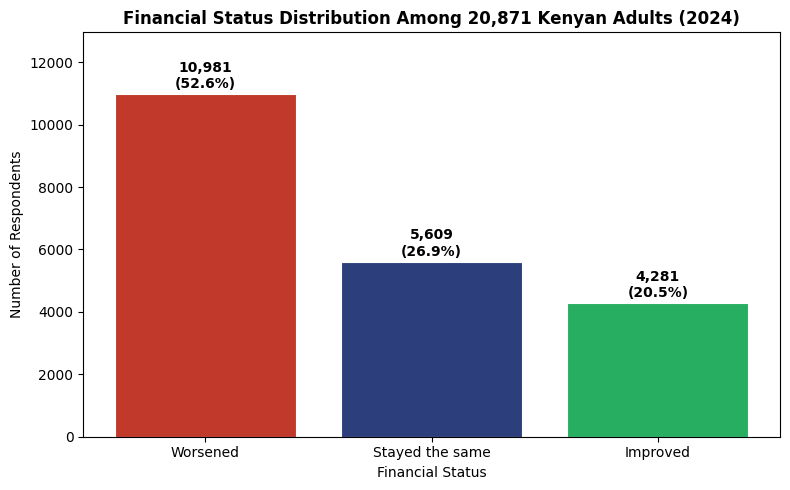

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
counts = df['financial_status'].value_counts()
colors = ['#C0392B', '#2C3E7B', '#27AE60']
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Financial Status Distribution Among 20,871 Kenyan Adults (2024)', fontweight='bold')
ax.set_xlabel('Financial Status')
ax.set_ylabel('Number of Respondents')
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.savefig('chart1_target_distribution.png', bbox_inches='tight')
plt.show()

From the bar chart above, we can see that for over half (52.6%) of the population, the financial situation worsened while for 26.9%, it more or less stayed the same and improved for 20.5% of the population. It is clear that there is a server class imbalance that has to be handled.

## Chart 2: Comparing Financial shock vs Financial status


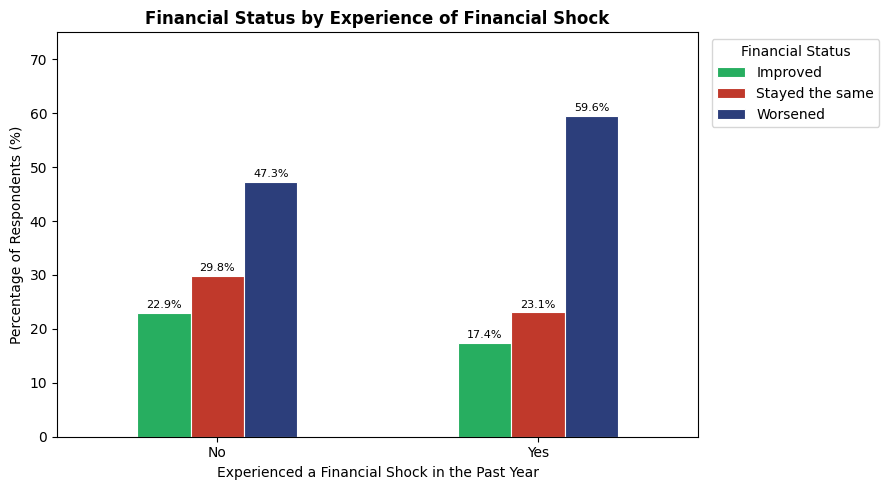

In [ ]:
shock_cross = pd.crosstab(df['experienced_shock'], df['financial_status'], normalize='index') * 100
fig, ax = plt.subplots(figsize=(9, 5))
shock_cross.plot(kind='bar', ax=ax, color=['#27AE60', '#C0392B', '#2C3E7B'],
                  edgecolor='white', linewidth=0.8, rot=0)
ax.set_title('Financial Status by Experience of Financial Shock', fontweight='bold')
ax.set_xlabel('Experienced a Financial Shock in the Past Year')
ax.set_ylabel('Percentage of Respondents (%)')
ax.legend(title='Financial Status', bbox_to_anchor=(1.01, 1), loc='upper left')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=2)
ax.set_ylim(0, 75)
plt.tight_layout()
plt.savefig('chart2_shock_vs_status.png', bbox_inches='tight')
plt.show()

From the chart, it is evident that for the individuals that experienced shock, the highest propotion is of those whose financial situation worsened.

## Chart 3: Montly income vs Financial status

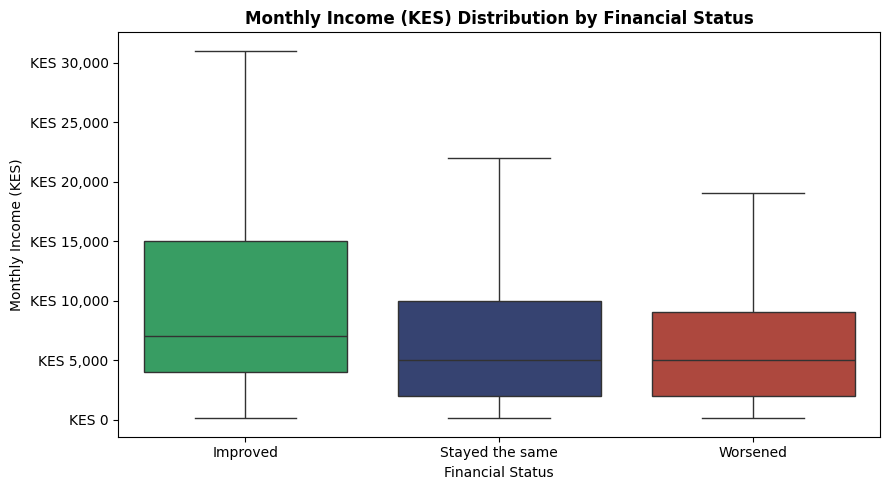

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
order = ['Improved', 'Stayed the same', 'Worsened']
palette = {'Improved': '#27AE60', 'Stayed the same': '#2C3E7B', 'Worsened': '#C0392B'}

sns.boxplot(data=df, x='financial_status', y='monthly_income', order=order,
            hue='financial_status', palette=palette, legend=False, showfliers=False, ax=ax)

ax.set_title('Monthly Income (KES) Distribution by Financial Status', fontweight='bold')
ax.set_xlabel('Financial Status')
ax.set_ylabel('Monthly Income (KES)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'KES {x:,.0f}'))
plt.tight_layout()
plt.savefig('chart2_income_vs_status.png', bbox_inches='tight')
plt.show()

According to our chart, there is minimal difference between the "stayed the same" and "worsened" financial status suggesting that while income might be a relevant differentiator,it is doesn't give mcuh information one whether someones's financial status stays the smaes or worsens.

## Chart 4: Education level vs financial status

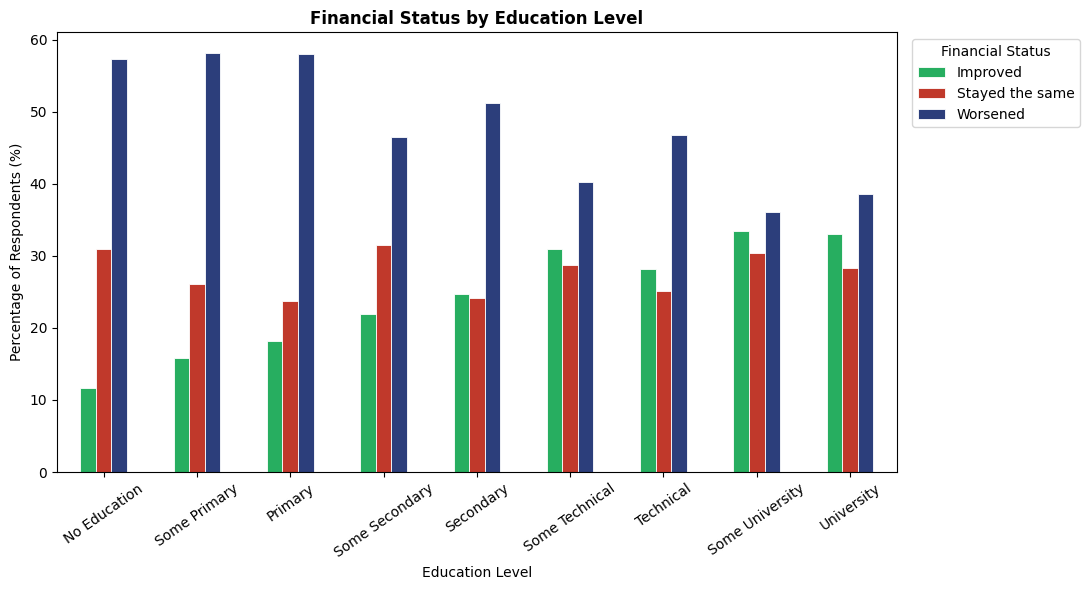

In [ ]:
# Clean education labels
edu_map = {
    '"None "': 'No Education',
    '"Some primary "': 'Some Primary',
    '"Primary completed"': 'Primary',
    '"Some secondary"': 'Some Secondary',
    '"Secondary completed "': 'Secondary',
    'Some technical training after secondary school': 'Some Technical',
    'Completed technical training after secondary school': 'Technical',
    'Some university': 'Some University',
    '"University completed "': 'University',
    '"Other (Specify) "': 'Other'
}
df['edu_clean'] = df['education_level'].map(edu_map).fillna('Other')

edu_order = ['No Education','Some Primary','Primary','Some Secondary',
             'Secondary','Some Technical','Technical','Some University','University']
edu_cross = pd.crosstab(df['edu_clean'], df['financial_status'], normalize='index') * 100
edu_cross = edu_cross.reindex([e for e in edu_order if e in edu_cross.index])

fig, ax = plt.subplots(figsize=(11, 6))
edu_cross.plot(kind='bar', ax=ax, color=['#27AE60', '#C0392B', '#2C3E7B'],
               edgecolor='white', linewidth=0.6, rot=35)
ax.set_title('Financial Status by Education Level', fontweight='bold')
ax.set_xlabel('Education Level')
ax.set_ylabel('Percentage of Respondents (%)')
ax.legend(title='Financial Status', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('chart4_education_vs_status.png', bbox_inches='tight')
plt.show()


The chart shows that a worsened financial situation correlates with lowe education. It is clear that as the level of education improves, the better their financial situation since individuals who have either completed or at least have some university education show a lower "worsened" proportion.

## Chart 5: Number of financial products used vs financial status

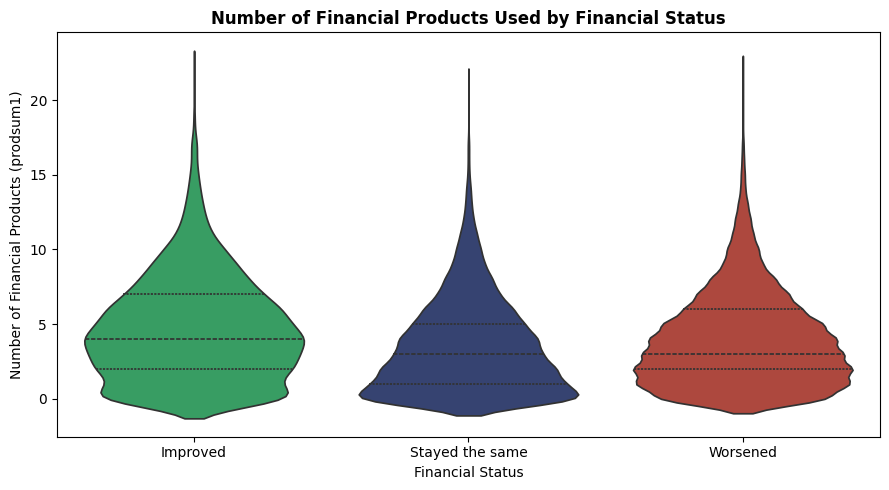

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
order = ['Improved', 'Stayed the same', 'Worsened']
palette = {'Improved': '#27AE60', 'Stayed the same': '#2C3E7B', 'Worsened': '#C0392B'}
sns.violinplot(data=df, x='financial_status', y='prodsum1', order=order,
               hue='financial_status', palette=palette, legend=False, inner='quartile', ax=ax)
ax.set_title('Number of Financial Products Used by Financial Status', fontweight='bold')
ax.set_xlabel('Financial Status')
ax.set_ylabel('Number of Financial Products (prodsum1)')
plt.tight_layout()
plt.savefig('chart5_prodsum_vs_status.png', bbox_inches='tight')
plt.show()

Individuals whose financial situation improved tended to use more financial products which may suggest that access to more financial products improve the financial status of an individual

## Chart six: Sex and Location vs Financial Status

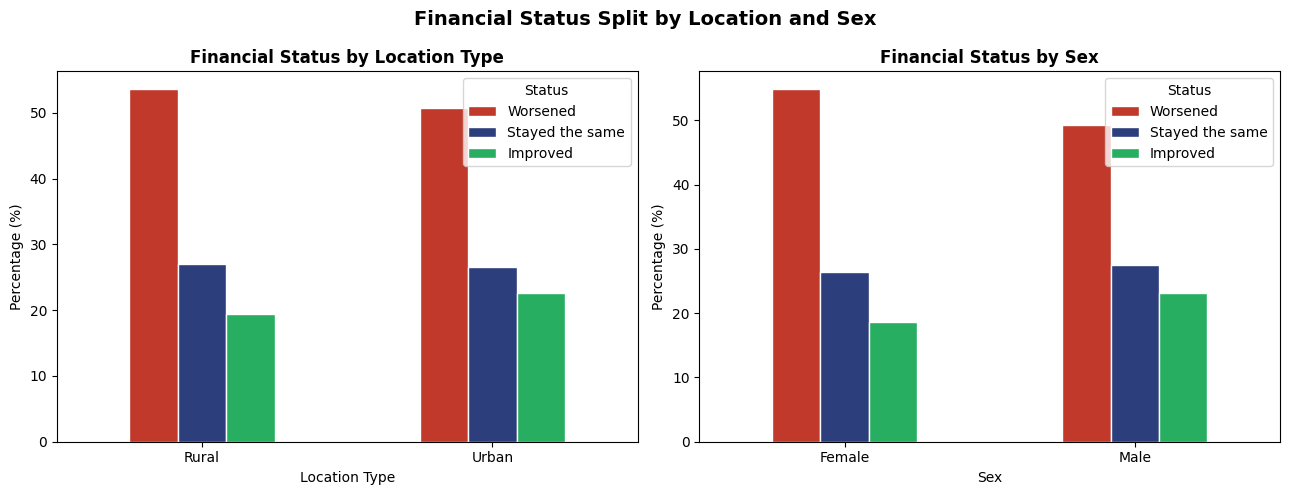

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

loc_cross = pd.crosstab(df['location_type'], df['financial_status'], normalize='index') * 100
loc_cross[['Worsened','Stayed the same','Improved']].plot(
    kind='bar', ax=axes[0], color=['#C0392B','#2C3E7B','#27AE60'],
    edgecolor='white', rot=0)
axes[0].set_title('Financial Status by Location Type', fontweight='bold')
axes[0].set_xlabel('Location Type')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(title='Status')

sex_cross = pd.crosstab(df['Sex'], df['financial_status'], normalize='index') * 100
sex_cross[['Worsened','Stayed the same','Improved']].plot(
    kind='bar', ax=axes[1], color=['#C0392B','#2C3E7B','#27AE60'],
    edgecolor='white', rot=0)
axes[1].set_title('Financial Status by Sex', fontweight='bold')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Status')

plt.suptitle('Financial Status Split by Location and Sex', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_location_sex.png', bbox_inches='tight')
plt.show()

Although the difference is very small, individuals in the rural areas make up a slighly higher percentage of those whose situation worsened compared to those in urban areas. Similarly, when it came to gender, more women made up the "worsened" proprotions compared to their male counterpart.

## Correlation map

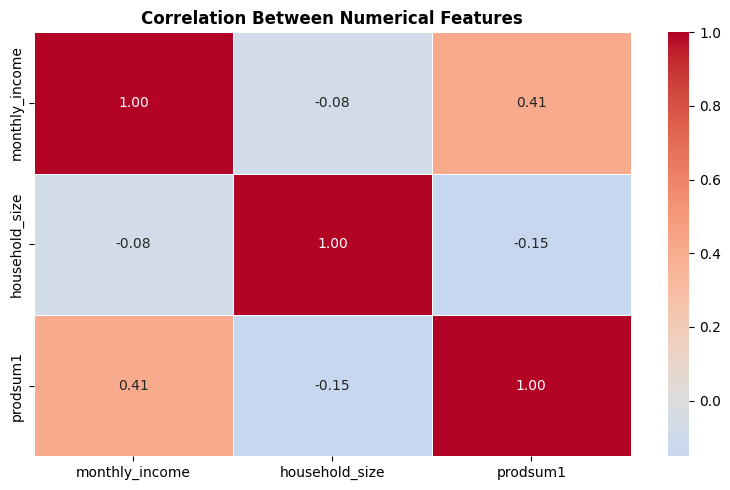

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

num_cols = ['monthly_income', 'household_size', 'prodsum1'] # Removed 'barriers_mobile_money'
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)

ax.set_title('Correlation Between Numerical Features', fontweight='bold')
plt.tight_layout()
plt.savefig('chart8_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Prepocessing

In [ ]:
df_model = df.copy()

# 4.1 Fill barriers_bank missing values
# Missing = person has a bank account (no barrier). Explicitly encode this.
df_model['barriers_bank'] = df_model['barriers_bank'].fillna('No barrier')
print("barriers_bank after fill:\n", df_model['barriers_bank'].value_counts())

barriers_bank after fill:
 barriers_bank
Affordability              10223
No barrier                  5734
Eligibility                 1499
Relevance/Suitability       1159
Access                      1045
Awareness                    959
Trust                        171
Other                         36
Charges/Product pricing       27
Service quality               18
Name: count, dtype: int64


In [ ]:
# Clean education labels
df_model['education_level'] = df_model['education_level'].map(edu_map).fillna('Other')

# Drop minor-age rows (16-17) — out of scope for policy analysis
df_model = df_model[df_model['Age'] != '16-17'].copy()
print(f"Rows after removing minors: {len(df_model)}")

# 4.4 Clean marital_status edge cases
df_model['marital_status'] = df_model['marital_status'].replace({
    "Don't know   (DO NOT READ OUT)": 'Unknown',
    'Refused to Answer(DO NOT READ OUT)': 'Unknown'
})

#  4.5 Feature Engineering
# Income band — real-world interpretation of income tiers in Kenya
df_model['income_band'] = pd.cut(df_model['monthly_income'],
                                  bins=[0, 2999, 9999, 29999, float('inf')],
                                  labels=['Low (<3k)', 'Lower-mid (3k-10k)',
                                          'Mid (10k-30k)', 'High (30k+)'])

# Drop edu_clean (was only for charting)
df_model.drop(columns=['edu_clean'], errors='ignore', inplace=True)

print("\nIncome band distribution:\n", df_model['income_band'].value_counts())

Rows after removing minors: 19750

Income band distribution:
 income_band
Lower-mid (3k-10k)    9069
Low (<3k)             4694
Mid (10k-30k)         4422
High (30k+)           1565
Name: count, dtype: int64


In [ ]:
# ── 4.6 Encode all categoricals ──────────────────────────────────────────
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'financial_status']
print(f"Encoding {len(cat_cols)} categorical columns: {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Also encode income_band (category dtype)
df_model['income_band'] = df_model['income_band'].cat.codes

# Encode target
target_map = {'Improved': 0, 'Stayed the same': 1, 'Worsened': 2}
df_model['financial_status_enc'] = df_model['financial_status'].map(target_map)
print("\nTarget encoding:", target_map)
df_model.head(3)

Encoding 24 categorical columns: ['county', 'location_type', 'Sex', 'Age', 'education_level', 'marital_status', 'Savings_formal', 'Savings_informal', 'Loan_formal', 'Loan_informal', 'defaulted', 'formal_service_use', 'mobile_money_access', 'barriers_mobile_money', 'mobile_ownership_1', 'experienced_shock', 'nfhi_11', 'nfhi_12', 'nfhi_13', 'accessto_13k_1month', 'not_difficult', 'fl_score', 'barriers_bank', 'has_disability']

Target encoding: {'Improved': 0, 'Stayed the same': 1, 'Worsened': 2}


,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability,income_band,financial_status_enc
0,6,1,0,1,5,8,1,30000,0,0,...,1,1,0,Stayed the same,0,3,5,1,3,1
1,6,1,0,4,11,0,1,10000,0,0,...,1,0,0,Worsened,3,1,1,1,2,2
2,3,1,0,1,2,2,0,3000,1,1,...,0,0,0,Improved,0,5,1,1,1,0


## Train/Test Split
Since our datatset is imbalanced, we will have to stratified splitting. Stratified splitting is a data sampling technique used in machine learning to divide a dataset into training and testing sets. It ensures that the proportion of target classes in both the training and testing datasets perfectly matches the proportions found in the original, unsplit dataset.

In [ ]:
feature_cols = [c for c in df_model.columns
                if c not in ['financial_status', 'financial_status_enc']]

# Drop rows where the target variable is NaN
df_model.dropna(subset=['financial_status_enc'], inplace=True)

x= df_model[feature_cols]
y = df_model['financial_status_enc']

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train size: {len(X_train):,} | Test size: {len(X_test):,}")
print(f"\nTrain class distribution:\n{y_train.value_counts(normalize=True).mul(100).round(1)}")
print(f"\nTest class distribution:\n{y_test.value_counts(normalize=True).mul(100).round(1)}")

Train size: 15,800 | Test size: 3,950

Train class distribution:
financial_status_enc
2    53.7
1    25.8
0    20.4
Name: proportion, dtype: float64

Test class distribution:
financial_status_enc
2    53.7
1    25.8
0    20.5
Name: proportion, dtype: float64


## Model Training

In [ ]:
# ── 6. Model Training ────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # ← use transform only, NOT fit_transform

# --- Model 1: Logistic Regression  ---
lr = LogisticRegression(
    class_weight='balanced',   # handles imbalance
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

f1_lr = f1_score(y_test, y_pred_lr, average='weighted')
print(f"Logistic Regression — Weighted F1: {f1_lr:.3f}")
print(classification_report(y_test, y_pred_lr,
      target_names=['Improved', 'Stayed the same', 'Worsened']))

Logistic Regression — Weighted F1: 0.498
                 precision    recall  f1-score   support

       Improved       0.35      0.57      0.43       808
Stayed the same       0.35      0.33      0.34      1020
       Worsened       0.68      0.54      0.60      2122

       accuracy                           0.49      3950
      macro avg       0.46      0.48      0.46      3950
   weighted avg       0.53      0.49      0.50      3950



In [ ]:
# --- Model 2: Random Forest ---
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',   # handles imbalance
    random_state=42,
    n_jobs=-1                  # use all CPU cores — faster
)
rf.fit(X_train, y_train)      # ← RF doesn't need scaling
y_pred_rf = rf.predict(X_test)

f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
print(f"Random Forest — Weighted F1: {f1_rf:.3f}")
print(classification_report(y_test, y_pred_rf,
      target_names=['Improved', 'Stayed the same', 'Worsened']))

Random Forest — Weighted F1: 0.503
                 precision    recall  f1-score   support

       Improved       0.45      0.22      0.30       808
Stayed the same       0.45      0.16      0.24      1020
       Worsened       0.59      0.88      0.71      2122

       accuracy                           0.56      3950
      macro avg       0.50      0.42      0.42      3950
   weighted avg       0.53      0.56      0.50      3950



Since the F1 F1 score of random forest is higher, it will be used moving foward.

## Evaluation charts

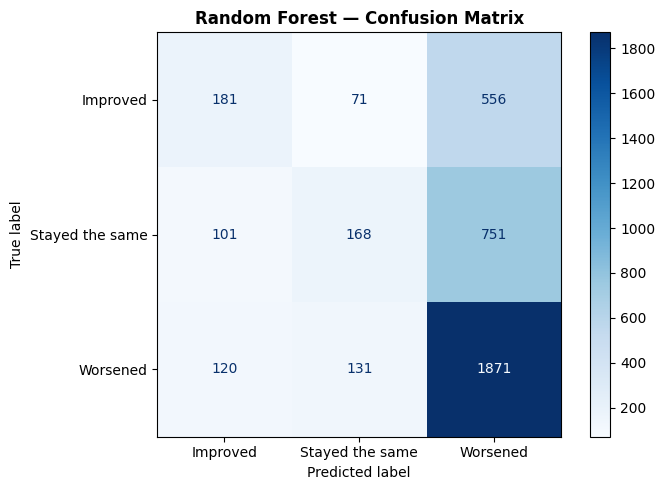

In [ ]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Improved', 'Stayed the same', 'Worsened'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Random Forest — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_confusion_matrix.png', bbox_inches='tight')
plt.show()

The model is strong at identifying "Worsened" (1,315 correct) but frequently mislabels "Improved" and "Stayed the same" as "Worsened".

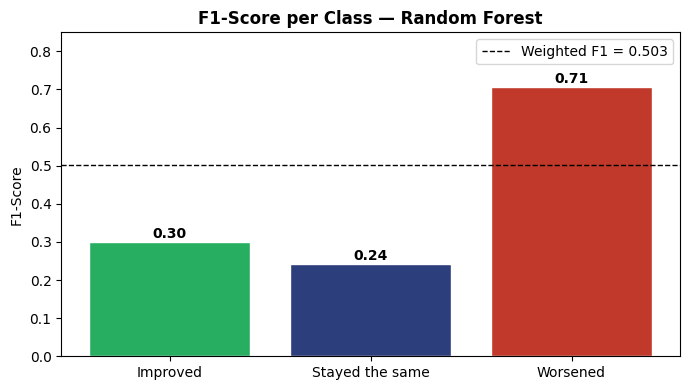

In [ ]:
# F1 per class — bar chart for slides
class_report = classification_report(
    y_test, y_pred_rf,
    target_names=['Improved', 'Stayed the same', 'Worsened'],
    output_dict=True
)

classes = ['Improved', 'Stayed the same', 'Worsened']
f1_scores = [class_report[c]['f1-score'] for c in classes]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(classes, f1_scores,
              color=['#27AE60', '#2C3E7B', '#C0392B'],
              edgecolor='white')
ax.axhline(f1_rf, linestyle='--', color='black', linewidth=1,
           label=f'Weighted F1 = {f1_rf:.3f}')
for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontweight='bold')
ax.set_ylim(0, 0.85)
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score per Class — Random Forest', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('chart_f1_per_class.png', bbox_inches='tight')
plt.show()

"Stayed the same" (0.23) is the hardest class — it sits in the middle and gets pulled toward both ends.

## Feature Importance

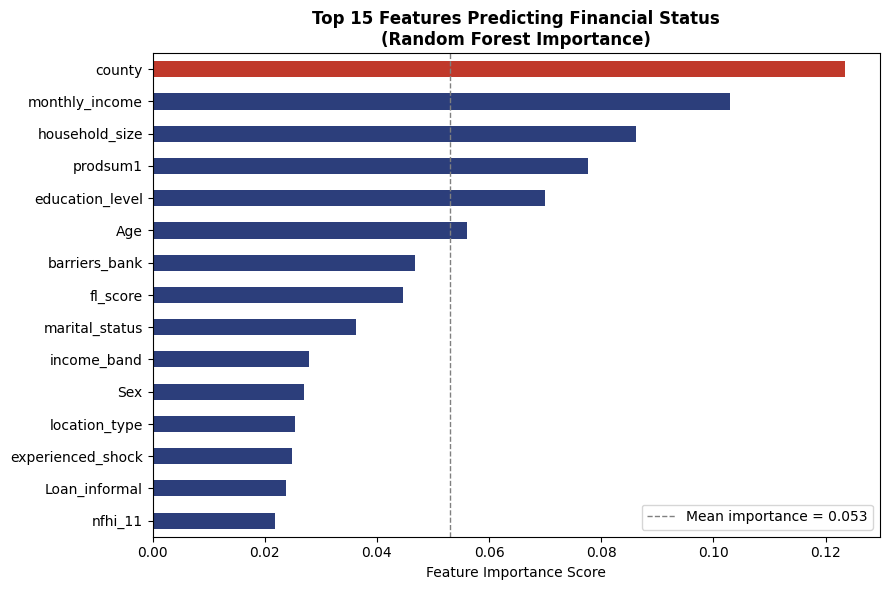


Top 15 features:
county               0.1235
monthly_income       0.1030
household_size       0.0861
prodsum1             0.0776
education_level      0.0701
Age                  0.0560
barriers_bank        0.0468
fl_score             0.0447
marital_status       0.0362
income_band          0.0280
Sex                  0.0270
location_type        0.0253
experienced_shock    0.0248
Loan_informal        0.0237
nfhi_11              0.0218


In [ ]:
# ── 8. Feature Importance ────────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#C0392B' if i == 0 else '#2C3E7B' for i in range(len(top15))]
top15.sort_values().plot(kind='barh', ax=ax, color=colors[::-1])

ax.set_title('Top 15 Features Predicting Financial Status\n(Random Forest Importance)',
             fontweight='bold')
ax.set_xlabel('Feature Importance Score')
ax.axvline(top15.mean(), linestyle='--', color='gray', linewidth=1,
           label=f'Mean importance = {top15.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('chart_feature_importance.png', bbox_inches='tight')
plt.show()

print("\nTop 15 features:")
print(top15.round(4).to_string())